In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/creditcardfraud/creditcard.csv


# Importing necessary modules

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Loading our dataset

In [3]:
df=pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Our data looks like its already been stardardized

# Analysing the data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Its a huge dataset with around 284k entries, 31 columns, and all our data is in numerical data type so theres no need to convert     
Also there are no null values in our data, which means theres no need of data cleaning to be done!!

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


There seems to be a lot of skewness in our data which can be visually analysed for better understanding

# Removing duplicate entries

In [6]:
df.duplicated().sum()

1081

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.shape

(283726, 31)

# Checking correlation 

In [9]:
df.corr().style.background_gradient()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,0.031068,-0.248536,0.125500,-0.065958,-0.100316,-0.184392,0.011286,-0.073819,0.090305,0.029537,-0.051022,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,0.000815,0.001028,-0.001524,-0.000568,-0.002663,-0.000602,-0.003345,-0.003491,-0.003535,0.000919,-0.001393,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,0.000620,-0.000633,0.002266,0.000680,0.002711,0.001538,0.004013,0.003244,0.002477,-0.000358,-0.001287,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,-0.009632,0.002339,-0.005900,0.000113,-0.003027,-0.001230,-0.004430,-0.008159,-0.003495,-0.000016,-0.002269,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,0.002753,-0.001223,0.003366,0.000177,0.002801,0.000572,0.003346,0.003655,0.002325,-0.000560,0.000318,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326
V5,0.173223,-0.007036,0.005210,-0.006879,0.001744,1.000000,-0.000938,-0.008709,0.001430,-0.001213,-0.006050,0.000411,-0.002342,0.000019,-0.001000,-0.001171,-0.002373,-0.004466,-0.002685,0.000436,-0.001185,0.001622,-0.000559,0.001183,0.000198,0.000069,0.000390,-0.005798,-0.000820,-0.387685,-0.087812
V6,-0.063279,0.000413,-0.000594,-0.001511,-0.000880,-0.000938,1.000000,0.000436,0.003036,-0.000734,-0.002180,-0.000211,-0.001185,0.000397,0.000184,-0.000470,0.000122,-0.001716,0.000541,0.000106,-0.000181,-0.002134,0.001104,-0.000755,0.001202,0.000697,-0.000028,0.000289,0.000925,0.216389,-0.043915
V7,0.085335,-0.009173,0.007425,-0.011721,0.004657,-0.008709,0.000436,1.000000,-0.006419,-0.004921,-0.013617,0.002454,-0.006153,-0.000170,-0.003816,-0.001394,-0.005944,-0.008794,-0.004279,0.000846,-0.001192,0.009010,-0.002280,0.003303,-0.000384,-0.000072,0.000624,-0.004537,0.001657,0.400408,-0.172347
V8,-0.038203,-0.001168,0.002899,-0.001815,0.000890,0.001430,0.003036,-0.006419,1.000000,0.001038,0.000481,0.004688,-0.004414,-0.001381,-0.008387,0.001044,-0.004376,-0.005576,-0.001323,-0.000626,0.000271,0.018892,-0.006156,0.004994,0.000113,0.000011,-0.001407,0.000613,-0.000099,-0.104662,0.033068
V9,-0.007861,0.001828,-0.000274,-0.003579,0.002154,-0.001213,-0.000734,-0.004921,0.001038,1.000000,-0.012613,-0.000217,-0.002385,0.000745,0.001981,-0.000283,-0.000086,-0.002318,-0.000373,0.000247,-0.001838,0.000679,0.000785,0.000677,-0.000103,-0.000275,0.001253,0.008221,0.005591,-0.044123,-0.094021


# Checking unique values in our dataset

In [10]:
df.nunique()

Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

Time
-0.03558045812827333


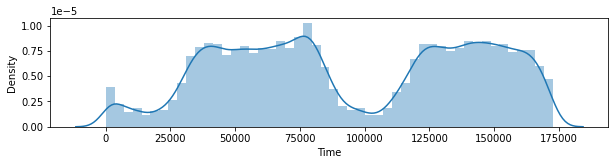

V1
-3.2732539433146486


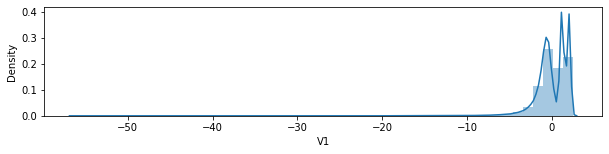

V2
-4.695137078165384


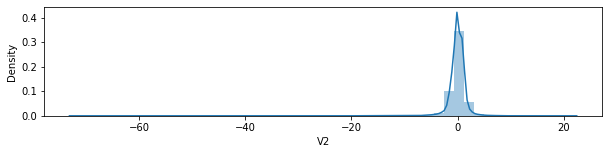

V3
-2.1519725799940685


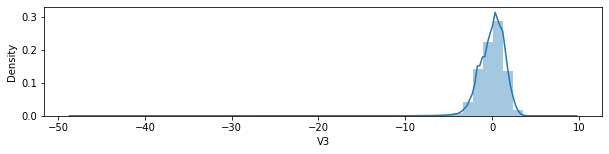

V4
0.6715006205655543


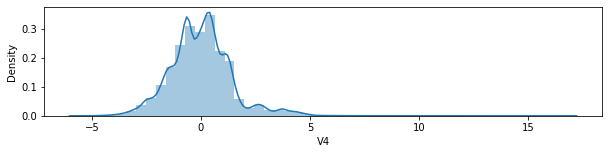

V5
-2.414066484215612


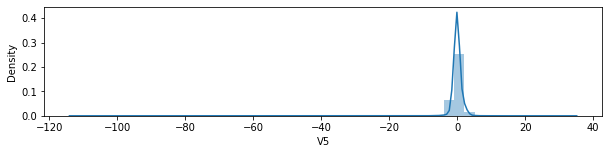

V6
1.829870709562578


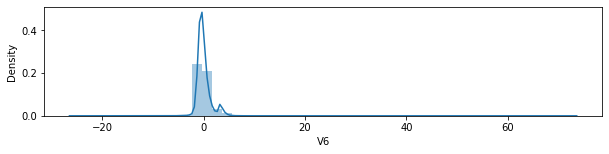

V7
2.8902559124339735


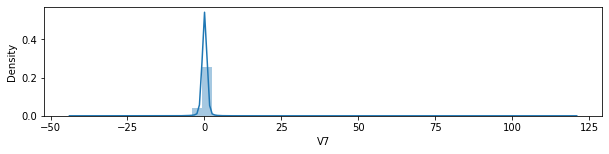

V8
-8.310926391626731


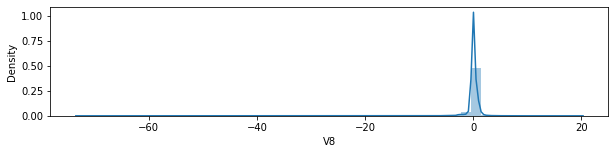

V9
0.5376602109334492


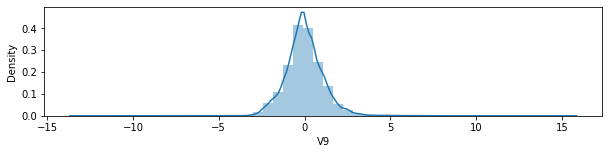

V10
1.2529604545622932


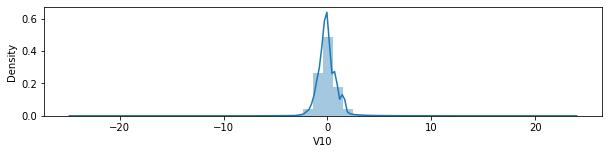

V11
0.34407237420591985


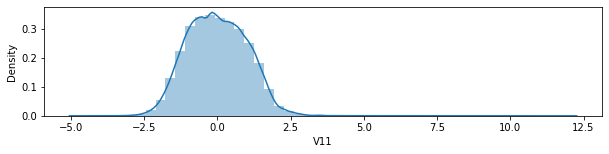

V12
-2.198996655901221


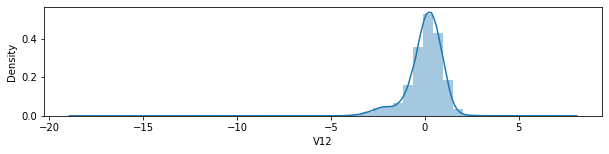

V13
0.06429306473390328


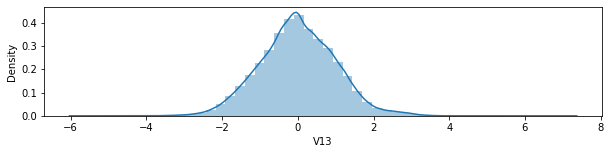

V14
-1.9187935694299705


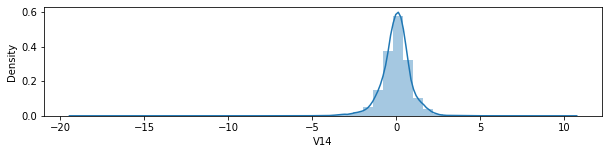

V15
-0.3096574451884751


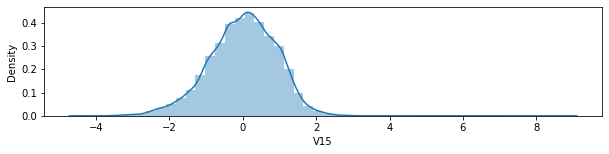

V16
-1.0511559142385323


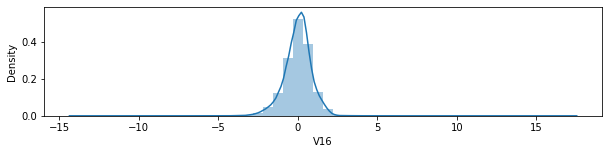

V17
-3.690477683233225


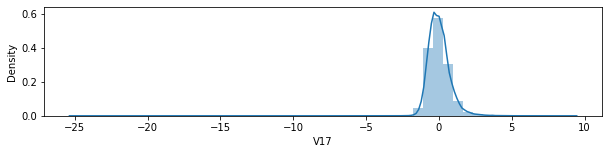

V18
-0.24866014274940992


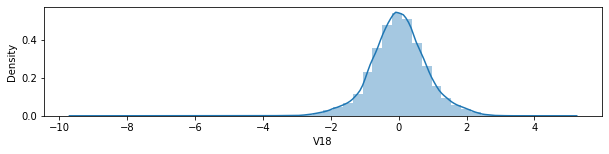

V19
0.1083112383097532


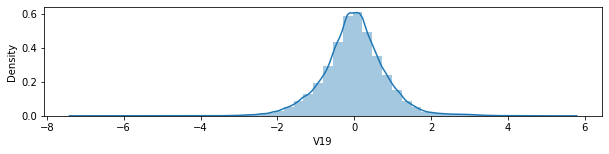

V20
-2.043110254457915


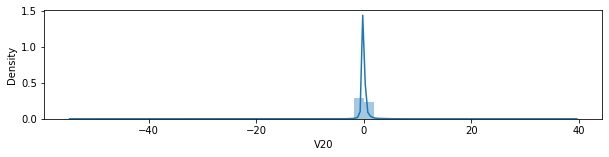

V21
2.8200182046255926


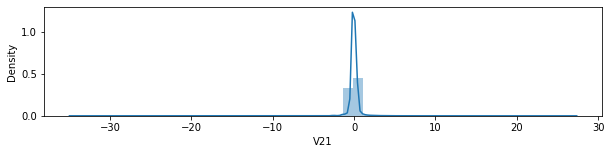

V22
-0.18232876403467282


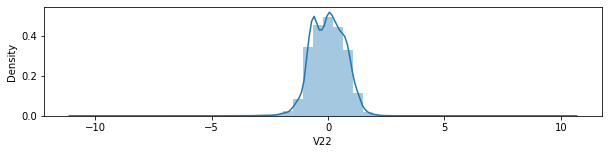

V23
-5.867189772192024


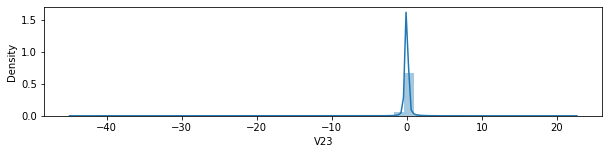

V24
-0.5521263176758532


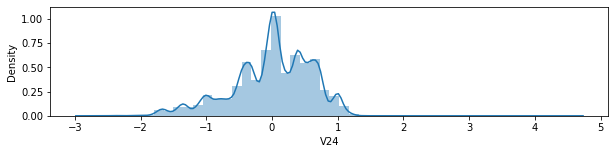

V25
-0.41574166410065255


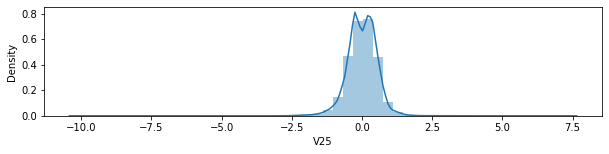

V26
0.5802892493462333


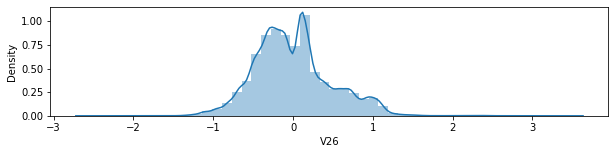

V27
-0.7537999286092231


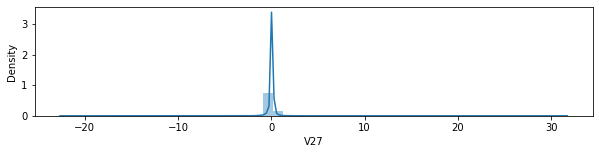

V28
11.555053994631207


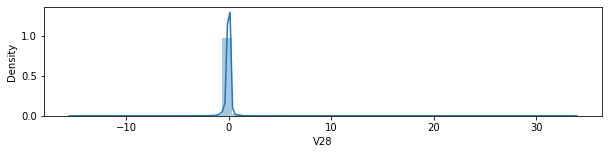

Amount
16.978713606547593


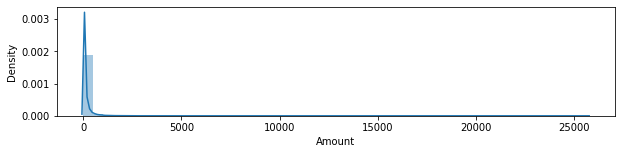

In [11]:
from scipy.stats import skew
col=df.columns[:-1]
for i in col:
    if (skew(df[i]>0.2)):
        print(i)
        print(skew(df[i]))
    
        plt.figure(figsize=(10,2))
        sns.distplot(df[i])
        plt.show()


# Checking target distribution

In [12]:
df['Class'].value_counts()

0    283253
1       473
Name: Class, dtype: int64

Our data seems to be highly imbalanced so we need to stratify and use GridSerachCrossValidation to obtain best results 

# Creating a new dataframe with balanced target data so our model can make accurate predictions

<AxesSubplot:xlabel='Class', ylabel='count'>

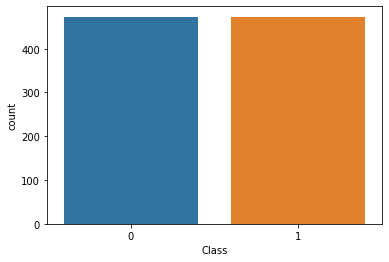

In [13]:
x=df.sample(473,random_state=1)[df['Class']==0]
y=df[df['Class']==1]
newdf=pd.concat([x,y],axis=0)
sns.countplot(data=newdf,x='Class')

Our data is now balanced and target is equally distributed 

In [14]:
newdf.sample(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
23422,32745.0,-2.179135,0.020218,-2.182733,2.572046,-3.663733,0.081568,0.268049,0.660437,-2.374027,...,1.026421,0.299614,1.656800,0.328433,0.106457,0.691775,0.196779,0.241085,717.15,1
68703,53105.0,-0.943300,1.077307,0.899209,0.051301,0.739595,0.692212,0.392665,0.085375,-0.512650,...,-0.158437,-0.341614,0.060050,-1.135469,-0.474003,0.225900,-0.105532,0.141718,2.69,0
65569,51646.0,1.169041,0.008089,-1.278646,0.082817,2.260878,3.294088,-0.170658,0.762516,-0.317839,...,-0.489200,-1.753792,0.137078,0.920116,0.387680,-0.827791,0.001732,0.033433,66.50,0
88960,62364.0,-1.017515,-0.723567,2.743896,-1.627490,-1.319368,-0.048112,0.187335,-0.315996,-0.549880,...,-0.143505,0.382609,0.090481,0.563494,-0.492882,0.873054,-0.491781,-0.273534,125.90,0
263274,160870.0,-0.644278,5.002352,-8.252739,7.756915,-0.216267,-2.751496,-3.358857,1.406268,-4.403852,...,0.587728,-0.605759,0.033746,-0.756170,-0.008172,0.532772,0.663970,0.192067,0.77,1
154719,102671.0,-4.991758,5.213340,-9.111326,8.431986,-3.435516,-1.827565,-7.114303,3.431207,-3.875643,...,1.189423,0.247858,0.294448,-0.548504,-0.174617,0.406703,-0.402339,-0.882886,0.00,1
43160,41397.0,-14.970346,8.401421,-16.867238,8.252334,-13.565130,-2.782438,-14.263735,9.643419,-7.701499,...,2.714045,-0.101355,-0.439666,0.519514,0.789328,0.064357,-1.621386,-1.104819,273.01,1
9252,13323.0,-5.454362,8.287421,-12.752811,8.594342,-3.106002,-3.179949,-9.252794,4.245062,-6.329801,...,1.846165,-0.267172,-0.310804,-1.201685,1.352176,0.608425,1.574715,0.808725,1.00,1
39308,39781.0,-0.208170,1.327463,-0.135795,1.001963,0.006445,-1.190252,0.682484,0.164992,-0.675286,...,0.186852,0.581661,0.107100,0.394818,-0.686848,-0.413449,0.308683,0.163503,19.13,0
2327,1869.0,-0.361625,1.472617,0.169055,0.129283,-0.034293,0.339019,-1.362315,-4.327297,-0.478627,...,-0.085571,-1.169874,0.188921,-0.514198,0.920566,0.211194,0.030006,0.151371,1.98,0


In [15]:
x=newdf.iloc[:,:-1]
y=newdf.iloc[:,-1]

In [16]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=2,test_size=0.25,stratify=y)

# Creating a function to test multiple model effectively

In [17]:
def mymodel(model):
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    
    tr=model.score(xtrain,ytrain)
    te=model.score(xtest,ytest)
    
    print(str(model)[:-2],'Accuracy: ',accuracy_score(ytest,ypred),\
          '\nConfusion Matrix: \n',confusion_matrix(ytest,ypred))
    print("Classification report: \n",classification_report(ytest,ypred))
    print(f'Training Accuracy: {tr}\nTesting Accuracy: {te}')
    
    return model

# Importing necessary models and metrics to check our model accuracy

In [18]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

In [19]:
knn=mymodel(KNeighborsClassifier())

KNeighborsClassifier Accuracy:  0.6540084388185654 
Confusion Matrix: 
 [[81 38]
 [44 74]]
Classification report: 
               precision    recall  f1-score   support

           0       0.65      0.68      0.66       119
           1       0.66      0.63      0.64       118

    accuracy                           0.65       237
   macro avg       0.65      0.65      0.65       237
weighted avg       0.65      0.65      0.65       237

Training Accuracy: 0.7602256699576869
Testing Accuracy: 0.6540084388185654


Not a good model as the accuracy is very low

In [20]:
svc=mymodel(SVC())

SVC Accuracy:  0.5443037974683544 
Confusion Matrix: 
 [[66 53]
 [55 63]]
Classification report: 
               precision    recall  f1-score   support

           0       0.55      0.55      0.55       119
           1       0.54      0.53      0.54       118

    accuracy                           0.54       237
   macro avg       0.54      0.54      0.54       237
weighted avg       0.54      0.54      0.54       237

Training Accuracy: 0.5331452750352609
Testing Accuracy: 0.5443037974683544


again not an effective model

In [21]:
dt=mymodel(DecisionTreeClassifier())

DecisionTreeClassifier Accuracy:  0.890295358649789 
Confusion Matrix: 
 [[105  14]
 [ 12 106]]
Classification report: 
               precision    recall  f1-score   support

           0       0.90      0.88      0.89       119
           1       0.88      0.90      0.89       118

    accuracy                           0.89       237
   macro avg       0.89      0.89      0.89       237
weighted avg       0.89      0.89      0.89       237

Training Accuracy: 1.0
Testing Accuracy: 0.890295358649789


Accuracy for Decision tree model is better but its also a case of overfitting which we dont want

In [22]:
gnb=mymodel(GaussianNB())

GaussianNB Accuracy:  0.8734177215189873 
Confusion Matrix: 
 [[119   0]
 [ 30  88]]
Classification report: 
               precision    recall  f1-score   support

           0       0.80      1.00      0.89       119
           1       1.00      0.75      0.85       118

    accuracy                           0.87       237
   macro avg       0.90      0.87      0.87       237
weighted avg       0.90      0.87      0.87       237

Training Accuracy: 0.8631875881523272
Testing Accuracy: 0.8734177215189873


Its so far the best model but lets check if we can find an even better model

In [23]:
lr=mymodel(LogisticRegression())

LogisticRegression Accuracy:  0.9409282700421941 
Confusion Matrix: 
 [[115   4]
 [ 10 108]]
Classification report: 
               precision    recall  f1-score   support

           0       0.92      0.97      0.94       119
           1       0.96      0.92      0.94       118

    accuracy                           0.94       237
   macro avg       0.94      0.94      0.94       237
weighted avg       0.94      0.94      0.94       237

Training Accuracy: 0.9337094499294781
Testing Accuracy: 0.9409282700421941


Perfect!...Logistic regression is giving the best accuracy with lowest recall and False positive and also the training and testing accuracy doesnt have a huge diff     
Its the best model !!

# Lets try using all data

In [24]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [25]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=2,\
                                           test_size=0.25,stratify=y)

In [26]:
y.value_counts()

0    283253
1       473
Name: Class, dtype: int64

# Training and testing all classification models to find the best one

In [27]:
#knn=mymodel(KNeighborsClassifier())

In [28]:
svc=mymodel(SVC())

SVC Accuracy:  0.9983364348953928 
Confusion Matrix: 
 [[70814     0]
 [  118     0]]
Classification report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.00      0.00      0.00       118

    accuracy                           1.00     70932
   macro avg       0.50      0.50      0.50     70932
weighted avg       1.00      1.00      1.00     70932

Training Accuracy: 0.9983317198793199
Testing Accuracy: 0.9983364348953928


In [29]:
lr=mymodel(LogisticRegression())

LogisticRegression Accuracy:  0.9989990413353634 
Confusion Matrix: 
 [[70783    31]
 [   40    78]]
Classification report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.72      0.66      0.69       118

    accuracy                           1.00     70932
   macro avg       0.86      0.83      0.84     70932
weighted avg       1.00      1.00      1.00     70932

Training Accuracy: 0.9989708356438621
Testing Accuracy: 0.9989990413353634


In [30]:
gnb=mymodel(GaussianNB())

GaussianNB Accuracy:  0.9920205267016298 
Confusion Matrix: 
 [[70292   522]
 [   44    74]]
Classification report: 
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     70814
           1       0.12      0.63      0.21       118

    accuracy                           0.99     70932
   macro avg       0.56      0.81      0.60     70932
weighted avg       1.00      0.99      0.99     70932

Training Accuracy: 0.9926078742821696
Testing Accuracy: 0.9920205267016298


In [31]:
dt=mymodel(DecisionTreeClassifier())

DecisionTreeClassifier Accuracy:  0.9990131393447246 
Confusion Matrix: 
 [[70781    33]
 [   37    81]]
Classification report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.71      0.69      0.70       118

    accuracy                           1.00     70932
   macro avg       0.86      0.84      0.85     70932
weighted avg       1.00      1.00      1.00     70932

Training Accuracy: 1.0
Testing Accuracy: 0.9990131393447246


**We can observe that when we use all the data our model is not effective even though its giving 99% accuracy but the prediction is mostly 0 as our model is learning on 0's and also the recall is very low so lets try with GridSearchCrossValidation**

# Cross Validation

In [32]:
x=df.iloc[:10000,:-1]
y=df.iloc[:10000,-1]

In [33]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=2,\
                                           test_size=0.25,stratify=y)

In [34]:
from sklearn.model_selection import GridSearchCV
parameters={'C':[0.1,10],'gamma':[0.1,0.01,0.001],'kernel':['rbf']}

grid=GridSearchCV(SVC(),parameters,verbose=2)
grid.fit(xtrain,ytrain)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   1.7s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   1.7s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   1.8s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   1.7s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   1.6s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   1.7s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   1.7s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   1.7s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   1.7s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   1.7s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.7s
[CV] END .....................C=0.1, gamma=0.001,

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 10], 'gamma': [0.1, 0.01, 0.001],
                         'kernel': ['rbf']},
             verbose=2)

In [35]:
grid.best_params_

{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}

In [36]:
grid.best_estimator_

SVC(C=10, gamma=0.001)

In [37]:
svm=grid.best_estimator_

In [38]:
svm.fit(xtrain,ytrain)
ypred=svm.predict(xtest)
    
tr=svm.score(xtrain,ytrain)
te=svm.score(xtest,ytest)
    
print('Accuracy: ',accuracy_score(ytest,ypred))
print("Classification report: \n",classification_report(ytest,ypred))
print(f'Training Accuracy: {tr}\nTesting Accuracy: {te}')

Accuracy:  0.9972
Classification report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2491
           1       1.00      0.22      0.36         9

    accuracy                           1.00      2500
   macro avg       1.00      0.61      0.68      2500
weighted avg       1.00      1.00      1.00      2500

Training Accuracy: 1.0
Testing Accuracy: 0.9972


**Not what we were expecting so lets keep trying with other models**

# to be continued.....Plz share suggestions :) ....THANKS!